# Analysis if NAT2, smoking and bladder cancer

This is the relationship between smoking and bladder cancer risk stratified by NAT2 genotype (rapid vs slow acetylators) according to [Davey Smith 2010](https://journals.sagepub.com/doi/full/10.1177/1745691610383505#bibr33-1745691610383505), reproduced from [Garcia-Closas 2006](https://pmc.ncbi.nlm.nih.gov/articles/PMC1459966/).

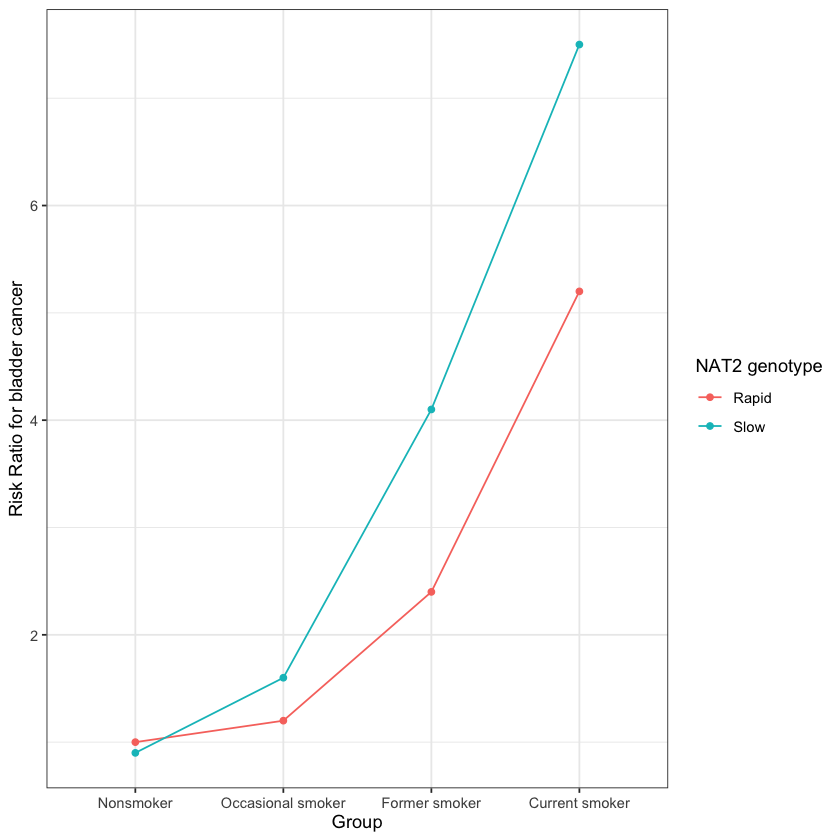

In [163]:
library(dplyr)
library(ggplot2)
ss <- tibble(
    Group = rep(factor(c("Nonsmoker", "Occasional smoker", "Former smoker", "Current smoker"), levels = c("Nonsmoker", "Occasional smoker", "Former smoker", "Current smoker")), times = 2),
    NAT2_group = rep(c("Rapid", "Slow"), each = 4),
    OR = c(1.0, 1.2, 2.4, 5.2, 0.9, 1.6, 4.1, 7.5)
) 
ggplot(ss, aes(x = Group, y = OR, group = NAT2_group, color = NAT2_group)) +
    geom_line() +
    geom_point() +
    theme_bw() +
    labs(y = "Risk Ratio for bladder cancer", color = "NAT2 genotype")

Generate a DAG that could explain this association:

![NAT2 and bladder cancer risk](dag.png)

Note that no interaction is required, but the effect of NAT2 on carcinogen levels is a relative effect, meaning that fast metabolisers will reduce carcinogen levels at a faster rate than slow metabolisers, but the additive change in carcinogen levels will be dependent on the initial level.

The model will look like:

$$
\text{logit}(P(Y=1)) = \beta_0 + \beta_{H,Y} H + \beta_{U,Y} U + E_Y
$$

Carcinogen intake:

$$
H_{intake} = \beta_{S,H} C + \beta_{U,H} U + E_H
$$

Carcinogen levels:

$$
H = \beta_{G_N,H} \times N \times H_{intake}
$$

NAT2 activity / levels:

$$
N = \beta_{G_N,N} G_N + E_N
$$

Smoking is represented as cigarettes per day, where G_I influences ever/never smoking and G_C influences number of cigarettes smoked per day among smokers.

$$
logit(P(S=1)) = \beta_{G_I,S} G_I + \beta_{U,S} U + E_S
$$

$C_i = 0$ if $S_i = 0$, otherwise 

$$
C = \beta_{G_C,C} G_C + \beta_{U,C} U + E_C
$$



where

- $N$ is the NAT2 gene activity level
- $H$ is the level of heterocyclic amines / carcinogens
- $S$ is smoking initiation (0 for never, 1 for ever)
- $C$ is the number of cigarettes smoked per day
- $Y$ is bladder cancer status (0/1)
- $G_1$ is the NAT2 genotype (2 for rapid, 1 for slow)



That describes the data generating model in the simulation below. Function for the data generating model:



In [164]:
dgm <- function(b_0, b_hy, b_uy, b_sh, b_nh, b_gcc, b_gis, b_gnn, b_us, b_uc, b_uh, n) {
    U <- runif(n)
    Gc <- rbinom(n, 2, 0.5)
    Gi <- rbinom(n, 2, 0.5)
    Gn <- rbinom(n, 1, 0.5) + 1
    logit_S <- b_gis * Gi + b_us * U + rnorm(n)
    S <- rbinom(n, 1, exp(logit_S) / (1 + exp(logit_S)))
    C <- ifelse(S == 0, 0, rpois(n, lambda = b_gcc * Gc + b_uc * U))
    N <- b_gnn * Gn + rnorm(n)
    H_intake <- b_sh * C + b_uh * U + rnorm(n)
    H <- H_intake * N * b_nh
    logit_p <- b_0 + b_hy * H + b_uy * U
    p <- exp(logit_p) / (1 + exp(logit_p))
    Y <- rbinom(n, 1, p)
    Ccat <- cut(C, breaks=c(-Inf, 0, 1, 2, 3, Inf), labels=c("0", "1", "2", "3", "4+"))    
    tibble(Y = Y, H = H, U = U, S = S, C = C, N = N, Gc = Gc, Gi = Gi, Gn = Gn, Ccat = Ccat)
}

[1] "ggplot2::ggplot" "ggplot"          "ggplot2::gg"     "S7_object"      
[5] "gg"

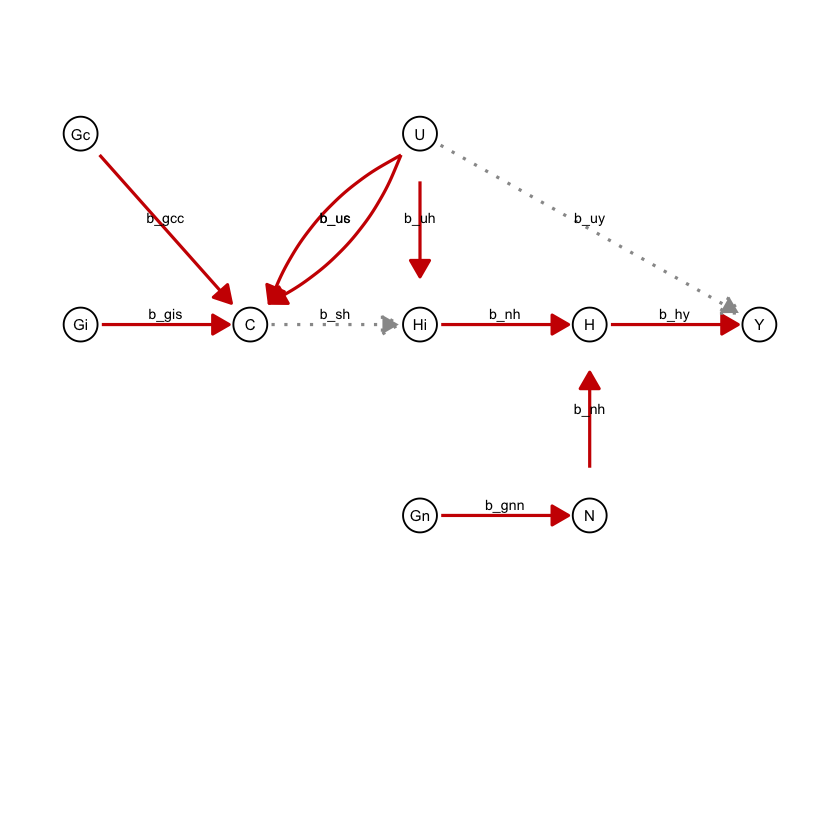

In [209]:
draw_dag <- function(b_hy, b_uy, b_sh, b_nh, b_gcc, b_gis, b_gnn, b_us, b_uc, b_uh) {
    nodes <- tibble::tribble(
        ~node,       ~x, ~y,
        "Gc",         1,  4,
        "Gi",         1,  3,
        "Gn",         5,  2,
        "U",          5,  4,
        "C",          3,  3,
        "N",          7,  2,
        "Hi",   5,  3,
        "H",          7,  3,
        "Y",          9,  3
    )

    edges <- tibble::tribble(
        ~from, ~to,        ~beta,   ~label,   ~curv,
        "Gc",  "C",        b_gcc,   "b_gcc",   0.00,
        "Gi",  "C",        b_gis,   "b_gis",   0,
        "U",   "C",        b_us,    "b_us",    0.20,
        "U",   "C",        b_uc,    "b_uc",   -0.20,
        "Gn",  "N",        b_gnn,   "b_gnn",   0.00,
        "C",   "Hi", b_sh,    "b_sh",    0.00,
        "U",   "Hi", b_uh,    "b_uh",    0.00,
        "Hi", "H",   b_nh,    "b_nh",    0.00,
        "N",   "H",        b_nh,    "b_nh",    0,
        "H",   "Y",        b_hy,    "b_hy",    0.00,
        "U",   "Y",        b_uy,    "b_uy",    0
    ) %>%
        dplyr::mutate(
            sign_type = dplyr::case_when(
                beta > 0 ~ "pos",
                beta < 0 ~ "neg",
                TRUE ~ "null"
            ),
            col = dplyr::case_when(
                sign_type == "pos" ~ "red3",
                sign_type == "neg" ~ "blue3",
                TRUE ~ "grey60"
            ),
            lty = ifelse(sign_type == "null", "dotted", "solid")
        ) %>%
        dplyr::left_join(nodes, by = c("from" = "node")) %>%
        dplyr::left_join(nodes, by = c("to" = "node"), suffix = c("", "end")) %>%
        dplyr::mutate(
            # Shorten arrows to stop at node edges
            dx = xend - x,
            dy = yend - y,
            length = sqrt(dx^2 + dy^2),
            # Shorten by 0.25 units at each end (approximate node radius)
            x = x + 0.25 * dx / length,
            y = y + 0.25 * dy / length,
            xend = xend - 0.25 * dx / length,
            yend = yend - 0.25 * dy / length
        )

    # Split edges into straight and curved
    edges_straight <- edges %>% dplyr::filter(curv == 0)
    edges_curved <- edges %>% dplyr::filter(curv != 0)
    
    p <- ggplot2::ggplot()
    
    # Add straight edges
    if (nrow(edges_straight) > 0) {
        p <- p + ggplot2::geom_segment(
            data = edges_straight,
            ggplot2::aes(
                x = x, y = y, xend = xend, yend = yend,
                color = col, linetype = lty
            ),
            arrow = grid::arrow(length = grid::unit(0.4, "cm"), type = "closed"),
            linewidth = 0.9
        )
    }
    
    # Add curved edges (one layer per unique curvature value)
    if (nrow(edges_curved) > 0) {
        for (curv_val in unique(edges_curved$curv)) {
            edges_subset <- edges_curved %>% dplyr::filter(curv == curv_val)
            p <- p + ggplot2::geom_curve(
                data = edges_subset,
                ggplot2::aes(
                    x = x, y = y, xend = xend, yend = yend,
                    color = col, linetype = lty
                ),
                curvature = curv_val,
                arrow = grid::arrow(length = grid::unit(0.4, "cm"), type = "closed"),
                linewidth = 0.9
            )
        }
    }
    
    p <- p +
        ggplot2::geom_text(
            data = edges,
            ggplot2::aes(
                x = (x + xend) / 2,
                y = (y + yend) / 2,
                label = label
            ),
            size = 3, vjust = -0.6
        ) +
        ggplot2::geom_point(
            data = nodes,
            ggplot2::aes(x = x, y = y),
            size = 9, shape = 21, fill = "white", color = "black", stroke = 0.8
        ) +
        ggplot2::geom_text(
            data = nodes,
            ggplot2::aes(x = x, y = y, label = node),
            size = 3.2
        ) +
        ggplot2::scale_color_identity() +
        ggplot2::scale_linetype_identity() +
        ggplot2::theme_void() +
        ggplot2::coord_cartesian(xlim = c(0.5, 9.5), ylim = c(0.5, 4.5))
    return(p)
}

a <- draw_dag(
    b_hy = 2,
    b_uy = 0,
    b_sh = 0,
    b_nh = 0.2,
    b_gcc = 1.0,
    b_gis = 1.0,
    b_gnn = 0.4,
    b_us = 2,
    b_uc = 2,
    b_uh = 3
)
class(a)
a

And this is the estimation model - the influence of smoking on bladder cancer stratified by NAT2 genotype

In [ ]:
estimation_gc2005 <- function(data) {
    model <- glm(Y ~ C * Gn, data = data, family = binomial)
    summary(model)
    p <- ggplot(rr, aes(x = Ccat, y = RR, group = Gn, color = factor(Gn))) +    return(p)
}

In [199]:
plot_rr <- function(data) {
    print(estimation_gc2005(data))
    rr <- estimation2(data)
    p <- ggplot(rr, aes(x = Ccat, y = RR, group = Gn, color = factor(Gn))) +
        geom_line() +
        geom_point() +
        theme_bw() +
        labs(y = "Risk Ratio for bladder cancer", color = "NAT2 genotype")
    return(p)
}

In [168]:
estimation2 <- function(data) {
    total_cases <- sum(data$Y)
    risk_baseline <- sum(data$Y[data$Ccat == 0 & data$Gn == 2]) / sum(data$Ccat == 0 & data$Gn == 2)
    group_by(data, Gn, Ccat) %>%
        do({
            cases <- sum(.$Y)
            n <- nrow(.)
            tibble(
                cases = cases,
                risk = cases / n,
                RR = risk / risk_baseline
            )
        })
}

In [215]:
analysis <- function(b_0, b_hy, b_uy, b_sh, b_nh, b_gcc, b_gis, b_gnn, b_us, b_uc, b_uh, n, plot=TRUE) {
    data <- dgm(b_0, b_hy, b_uy, b_sh, b_nh, b_gcc, b_gis, b_gnn, b_us, b_uc, b_uh, n)
    p1 <- draw_dag(b_hy, b_uy, b_sh, b_nh, b_gcc, b_gis, b_gnn, b_us, b_uc, b_uh)
    p2 <- plot_rr(data)
    # plot p1 and p2 side by side
    if (plot) {
        gridExtra::grid.arrange(p1, p2, nrow = 2)
    }
}

Example dataset with no confounding:


Call:
glm(formula = Y ~ C * Gn, family = binomial, data = data)

Coefficients:
             Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -3.017419   0.016172 -186.586  < 2e-16 ***
C            0.279439   0.008410   33.226  < 2e-16 ***
Gn           0.049788   0.010129    4.915 8.86e-07 ***
C:Gn         0.122449   0.005214   23.487  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 540876  on 999999  degrees of freedom
Residual deviance: 510289  on 999996  degrees of freedom
AIC: 510297

Number of Fisher Scoring iterations: 5



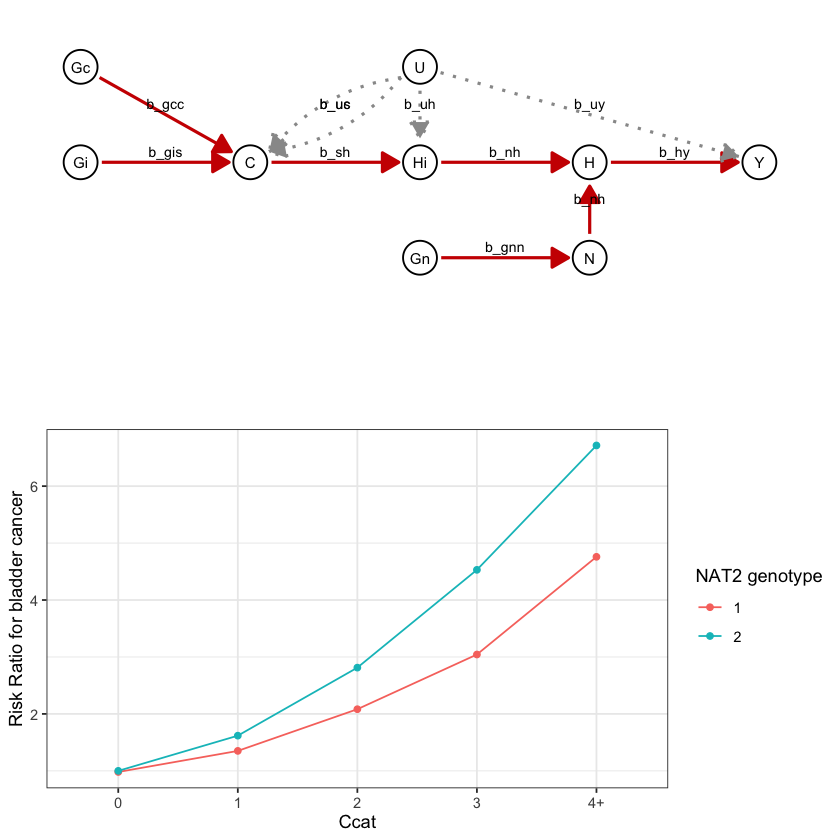

In [216]:
analysis(
    b_0 = -3,
    b_hy = 1.3,
    b_sh = 2,
    b_nh = 0.2,
    b_gcc = 1.0,
    b_gis = 1.0,
    b_gnn = 0.4,
    b_us = 0,
    b_uc = 0,
    b_uh = 0,
    b_uy = 0,
    n = 1000000
)

So this generates a G x smoking interaction on breast cancer with no marginal effect that is pretty close to the empirical results

Smoking is not causal: leads to no smoking assoc and no interaction with smoking


Call:
glm(formula = Y ~ C * Gn, family = binomial, data = data)

Coefficients:
             Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -2.968793   0.017093 -173.683   <2e-16 ***
C           -0.005902   0.013108   -0.450    0.653    
Gn           0.013573   0.010789    1.258    0.208    
C:Gn         0.001912   0.008272    0.231    0.817    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 395345  on 999999  degrees of freedom
Residual deviance: 395341  on 999996  degrees of freedom
AIC: 395349

Number of Fisher Scoring iterations: 5



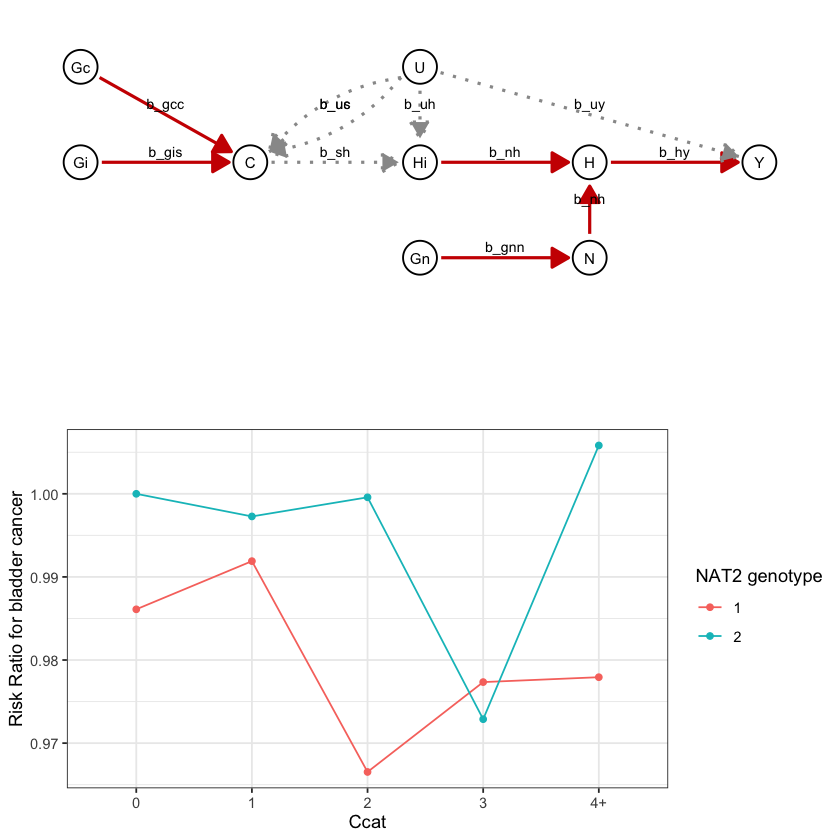

In [217]:
analysis(
    b_0 = -3,
    b_hy = 1.3,
    b_sh = 0,
    b_nh = 0.2,
    b_gcc = 1.0,
    b_gis = 1.0,
    b_gnn = 0.4,
    b_us = 0,
    b_uc = 0,
    b_uh = 0,
    b_uy = 0,
    n = 1000000
)

Scenario: Smoking is not causal but is positively confounded with H_intake

This leads to an interaction as well as marginal effects for smoking and Gn.


Call:
glm(formula = Y ~ C * Gn, family = binomial, data = data)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -2.873349   0.019259 -149.19   <2e-16 ***
C            0.057510   0.003605   15.95   <2e-16 ***
Gn           0.216609   0.011806   18.35   <2e-16 ***
C:Gn         0.024042   0.002199   10.93   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 668739  on 999999  degrees of freedom
Residual deviance: 658818  on 999996  degrees of freedom
AIC: 658826

Number of Fisher Scoring iterations: 5



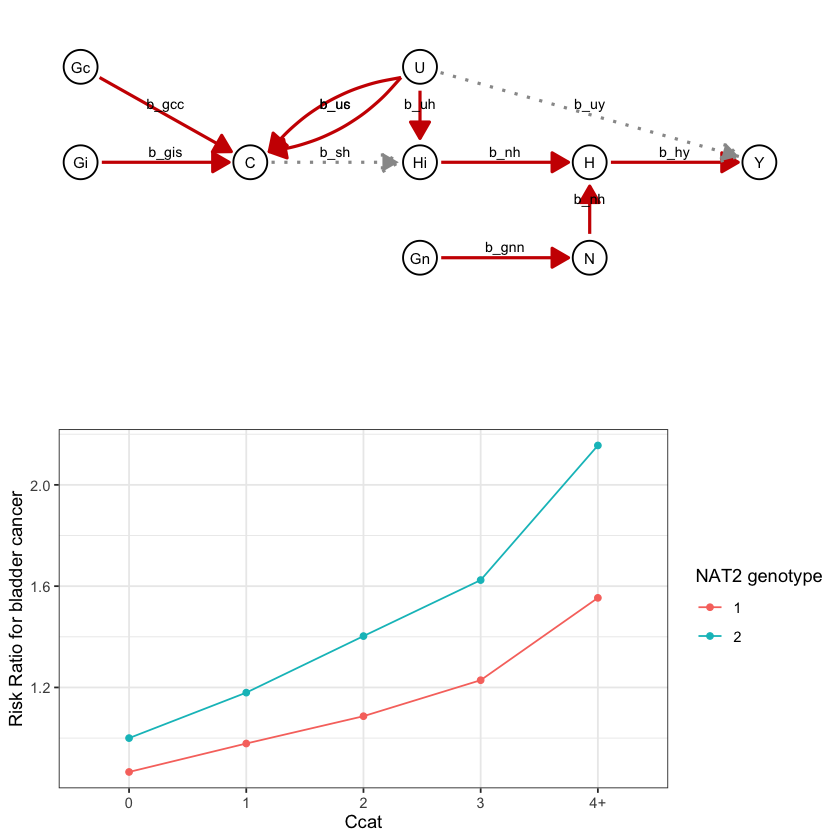

In [218]:
analysis(
    b_0 = -3,
    b_hy = 1.3,
    b_sh = 0,
    b_nh = 0.2,
    b_gcc = 1.0,
    b_gis = 1.0,
    b_gnn = 0.4,
    b_us = 6,
    b_uc = 6,
    b_uh = 6,
    b_uy = 0,
    n = 1000000
)

Scenario: Smoking is causal and confounded

How different is this to a scenario where smoking is causal and there are also confounders?

The shape is basically the same as when smoking was not causal


Call:
glm(formula = Y ~ C * Gn, family = binomial, data = data)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -2.807549   0.017255 -162.71   <2e-16 ***
C            0.129645   0.003043   42.60   <2e-16 ***
Gn           0.240679   0.010579   22.75   <2e-16 ***
C:Gn         0.036419   0.001874   19.44   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 889216  on 999999  degrees of freedom
Residual deviance: 842780  on 999996  degrees of freedom
AIC: 842788

Number of Fisher Scoring iterations: 4



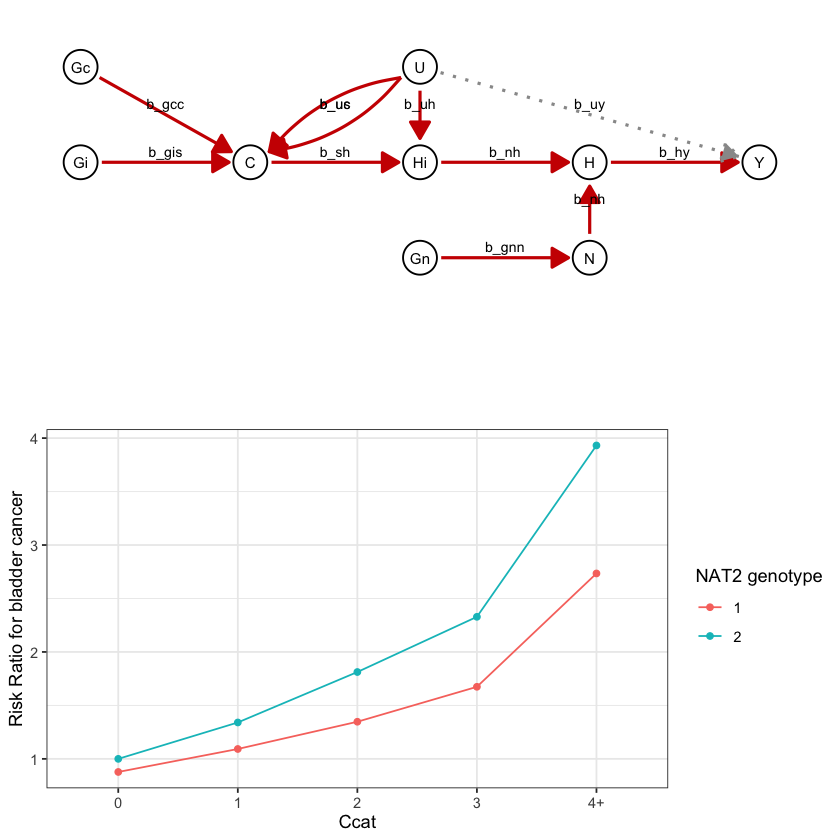

In [219]:
analysis(
    b_0 = -3,
    b_hy = 1.3,
    b_sh = 0.5,
    b_nh = 0.2,
    b_gcc = 1.0,
    b_gis = 1.0,
    b_gnn = 0.4,
    b_us = 6,
    b_uc = 6,
    b_uh = 6,
    b_uy = 0,
    n = 1000000
)

Scenario: Smoking not causal but confounded with the outcome

What about if smoking is confounded with the outcome rather than Hi

This leads to no interaction


Call:
glm(formula = Y ~ C * Gn, family = binomial, data = data)

Coefficients:
              Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -1.9953123  0.0144104 -138.463   <2e-16 ***
C            0.1681301  0.0026659   63.067   <2e-16 ***
Gn           0.0100812  0.0091044    1.107    0.268    
C:Gn        -0.0001044  0.0016852   -0.062    0.951    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1049845  on 999999  degrees of freedom
Residual deviance: 1009118  on 999996  degrees of freedom
AIC: 1009126

Number of Fisher Scoring iterations: 4



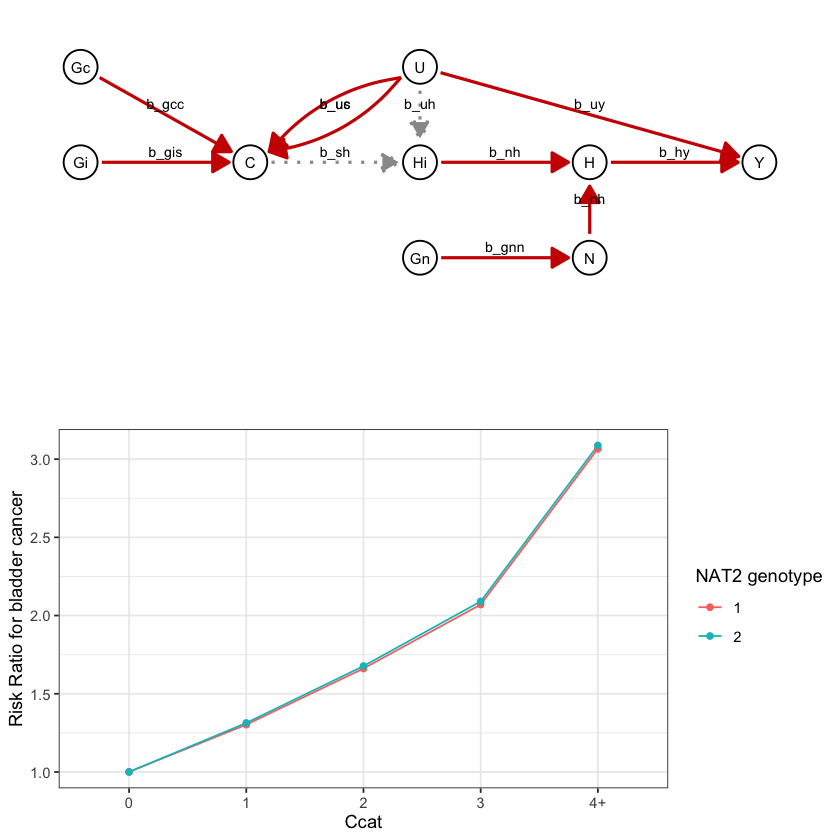

In [220]:
analysis(
    b_0 = -3,
    b_hy = 1.3,
    b_sh = 0,
    b_nh = 0.2,
    b_gcc = 1.0,
    b_gis = 1.0,
    b_gnn = 0.4,
    b_us = 6,
    b_uc = 6,
    b_uh = 0,
    b_uy = 3,
    n = 1000000
)

Scenario: Smoking is causal and it is confounded with the outcome

This induces the interaction, but it also makes the smoking - risk ratio relationship more linear


Call:
glm(formula = Y ~ C * Gn, family = binomial, data = data)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -0.938695   0.011947 -78.569   <2e-16 ***
C            0.195352   0.002881  67.802   <2e-16 ***
Gn           0.006485   0.007647   0.848    0.396    
C:Gn         0.104373   0.001913  54.548   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1362260  on 999999  degrees of freedom
Residual deviance: 1180523  on 999996  degrees of freedom
AIC: 1180531

Number of Fisher Scoring iterations: 4



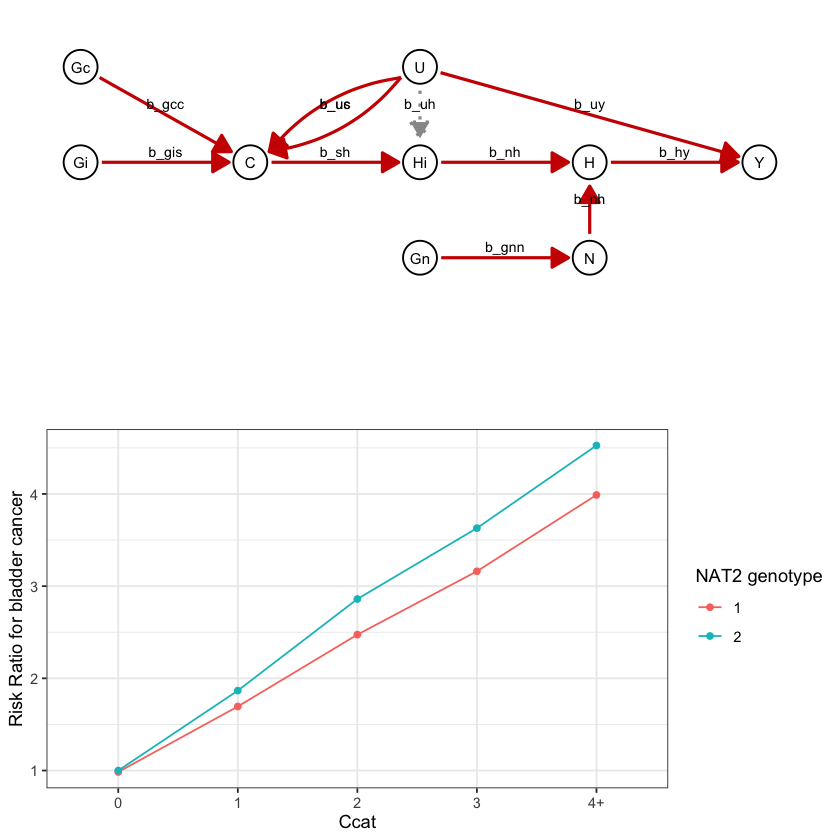

In [228]:
analysis(
    b_0 = -3,
    b_hy = 1.3,
    b_sh = 2,
    b_nh = 0.2,
    b_gcc = 1.0,
    b_gis = 1.0,
    b_gnn = 0.4,
    b_us = 6,
    b_uc = 6,
    b_uh = 0,
    b_uy = 6,
    n = 1000000
)

Scenario: Smoking is causal and it is negatively confounded with the outcome

This induces the interaction, but it also makes the smoking - risk ratio relationship more non-linear


Call:
glm(formula = Y ~ C * Gn, family = binomial, data = data)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -4.279189   0.028964 -147.74   <2e-16 ***
C            0.171179   0.004497   38.06   <2e-16 ***
Gn           0.293287   0.017423   16.83   <2e-16 ***
C:Gn         0.046999   0.002704   17.38   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 482004  on 999999  degrees of freedom
Residual deviance: 442950  on 999996  degrees of freedom
AIC: 442958

Number of Fisher Scoring iterations: 6



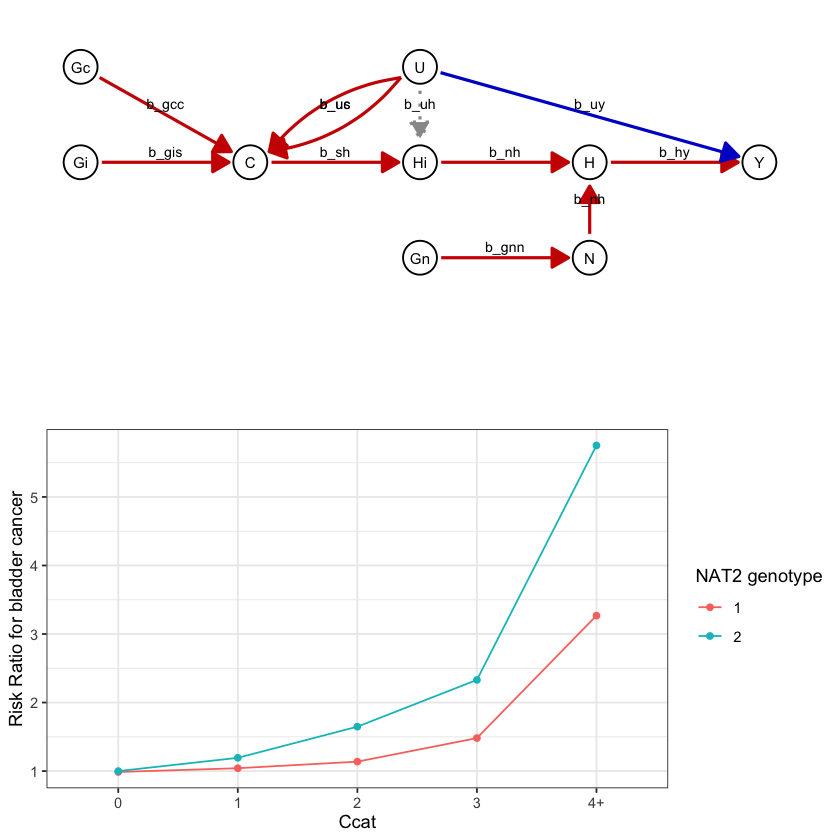

In [229]:
analysis(
    b_0 = -3,
    b_hy = 1.3,
    b_sh = 2,
    b_nh = 0.2,
    b_gcc = 1.0,
    b_gis = 1.0,
    b_gnn = 0.4,
    b_us = 6,
    b_uc = 6,
    b_uh = 0,
    b_uy = -6,
    n = 1000000
)

Scenario: All confounding paths and no causality

Largely similar to the confounding of smoking - Hi example. 


Call:
glm(formula = Y ~ C * Gn, family = binomial, data = data)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -1.213119   0.012237  -99.14   <2e-16 ***
C            0.306447   0.002906  105.46   <2e-16 ***
Gn           0.084446   0.007743   10.91   <2e-16 ***
C:Gn         0.029525   0.001866   15.82   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1377802  on 999999  degrees of freedom
Residual deviance: 1194068  on 999996  degrees of freedom
AIC: 1194076

Number of Fisher Scoring iterations: 4



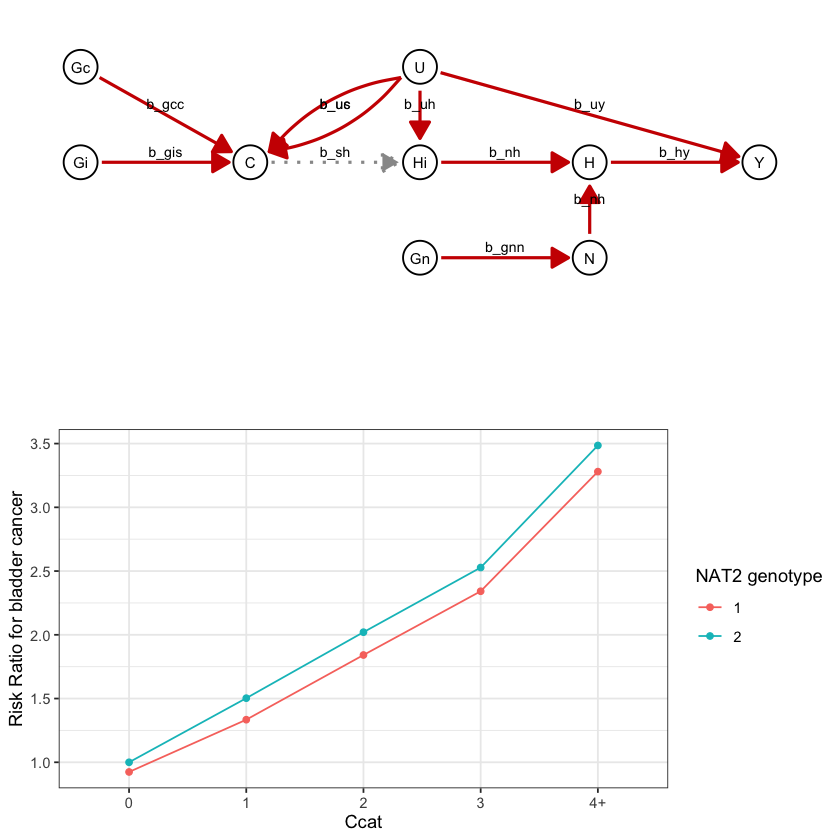

In [230]:
analysis(
    b_0 = -3,
    b_hy = 1.3,
    b_sh = 0,
    b_nh = 0.2,
    b_gcc = 1.0,
    b_gis = 1.0,
    b_gnn = 0.4,
    b_us = 6,
    b_uc = 6,
    b_uh = 6,
    b_uy = 6,
    n = 1000000
)

Scenario: All confounding paths and causality

As above


Call:
glm(formula = Y ~ C * Gn, family = binomial, data = data)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -0.912855   0.011668  -78.23   <2e-16 ***
C            0.175449   0.002789   62.91   <2e-16 ***
Gn           0.106547   0.007449   14.30   <2e-16 ***
C:Gn         0.093723   0.001852   50.60   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1354648  on 999999  degrees of freedom
Residual deviance: 1200465  on 999996  degrees of freedom
AIC: 1200473

Number of Fisher Scoring iterations: 4



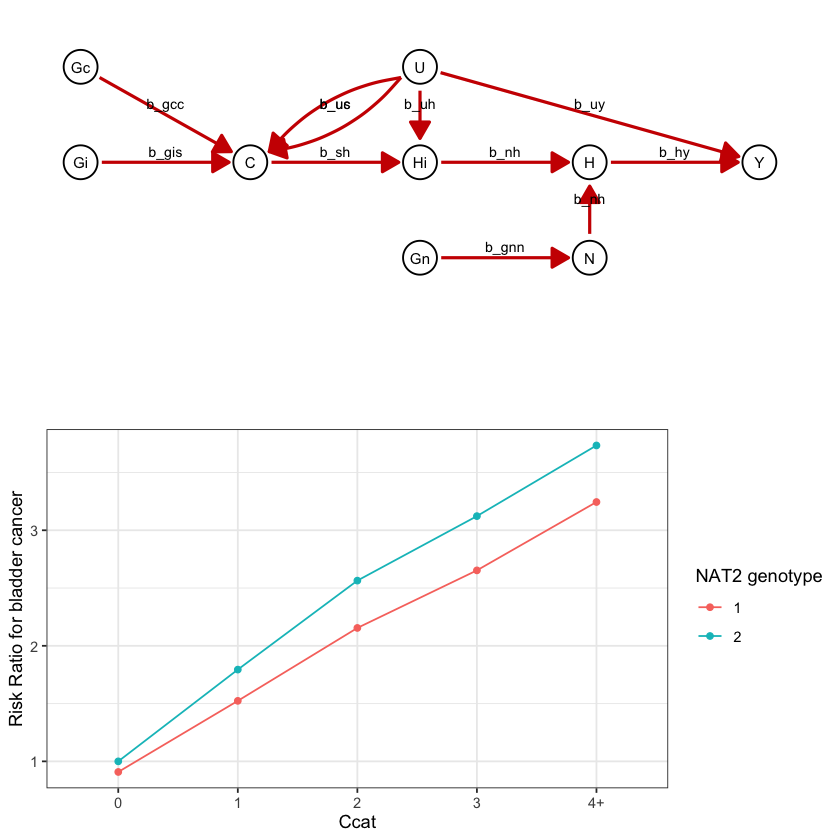

In [231]:
analysis(
    b_0 = -3,
    b_hy = 1.3,
    b_sh = 2,
    b_nh = 0.2,
    b_gcc = 1.0,
    b_gis = 1.0,
    b_gnn = 0.4,
    b_us = 6,
    b_uc = 6,
    b_uh = 6,
    b_uy = 6,
    n = 1000000
)

## Summary

- The signature of causality is that exposure associates with the outcome and the buffering mechanism interacts with exposure
- Confounding of exposure - mediator will lead to the intercept being non-1 for one of the genotype classes
- Unfortunately confounding of the exposure - mediator will give the same pattern whether or not the exposure is causal
- We can separate exposure-outcome confounding from exposure-outcome causality
- We cannot separate exposure-mediator confounding from exposure-outcome causality
- Could investigate fitting multiple exposures 